In [1]:
import pandas as pd # process and manipulate table data, implementing operations such as loading, aligning, merging, and transforming datasets efficiently
import numpy as np # numerical computing library for working with arrays and matrices, providing mathematical functions to operate on these data structures
import matplotlib.pyplot as plt # plotting library for creating static, animated, and interactive visualizations in Python
import os   # operating system interfaces for file and directory manipulation
import warnings # warning control to suppress or manage warning messages
import gsw  # Gibbs SeaWater (TEOS-10) oceanographic toolbox for seawater property calculations

# Suppress pandas parsing warnings
warnings.filterwarnings('ignore', message="Could not infer format") 

# Water Surface Elevation Method

 This code calculates water surface elevation from the MeterCTD. Depth is derived some a simple power gain that is not available for public use. MeterCTD position is estimated from the surveyed OWLR to the NAVD88 Datum. The water level sensor on the OWLR is positioned at 846.8 cm above sealevel. CTD_hourly is calculated using two values. The value "706.14" is the estimated offset between the OWLR sensor and the MeterCTD in centimeters. The value "30.48" is the conversion factor from feet to centimeters.





Window: 2026-01-28 11:00:00 to 2026-04-15 12:00:00
Hourly CTD points in window: 1849
OWLR hourly points in window: 1843
Matched comparison points: 1838


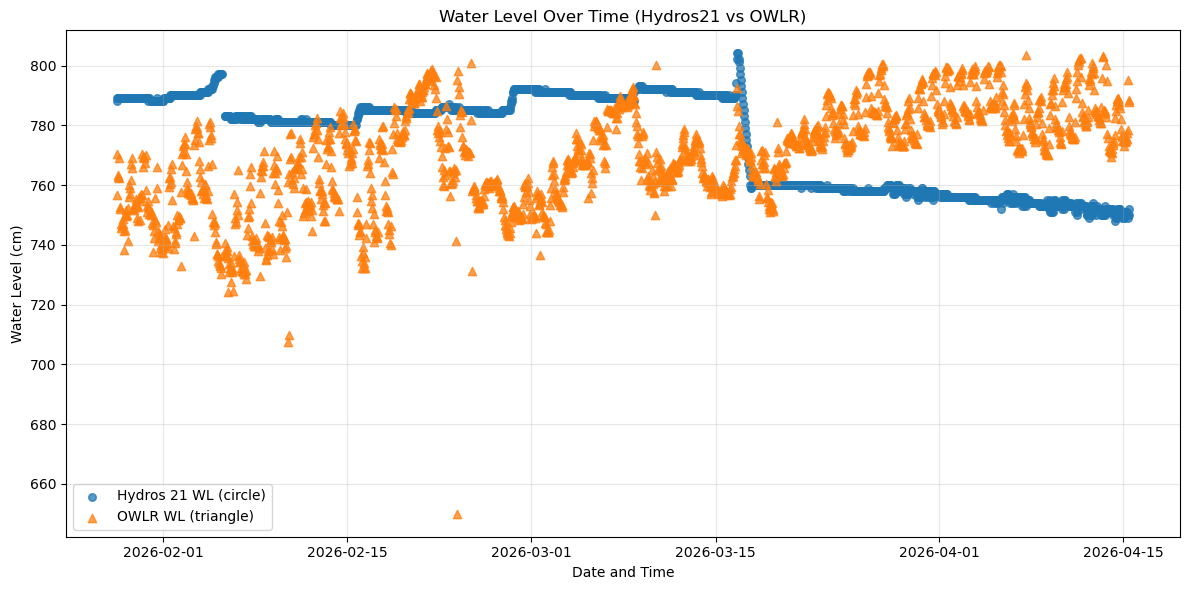

,timestamp_hour,WSE_CTD_cm,WSE_OWLR_cm
0,2026-01-28 11:00:00,788.14,770.388195
1,2026-01-28 12:00:00,789.14,756.761110
2,2026-01-28 13:00:00,789.14,763.354160
3,2026-01-28 14:00:00,789.14,762.859730
4,2026-01-28 15:00:00,789.14,762.475000


In [3]:
# File paths
wse_CTD_path = os.path.join('Data', 'wse_meterCTD_04152026.csv')
owlr_path = os.path.join('Data', 'OWLR_CMS_04152026.csv')
temp_path = os.path.join('Data', 'distance_BriefOWL.csv')  # Not used in current analysis but available for future use

# Required comparison window
start_time = pd.Timestamp('2026-01-28 11:00:00')
end_time = pd.Timestamp('2026-04-15 12:00:00')

# Load CTD depth 
# skipping 5 metadata lines 
try:
    CTD_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='utf-8')
except UnicodeDecodeError:
    try:
        CTD_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='cp1252')
    except UnicodeDecodeError:
        CTD_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='latin1')
CTD_raw.columns = [str(c).strip() for c in CTD_raw.columns]

# CTD columns
CTD_time_col  = CTD_raw.columns[0]
CTD_depth_col = CTD_raw.columns[1]

CTD_raw[CTD_time_col]  = pd.to_datetime(CTD_raw[CTD_time_col],  errors='coerce')
CTD_raw[CTD_depth_col] = pd.to_numeric(CTD_raw[CTD_depth_col],  errors='coerce')

# Keep Hourly ctd marks, no summing like with rainfall
CTD_hourly = CTD_raw[
    CTD_raw[CTD_time_col].notna()
    & (CTD_raw[CTD_time_col].dt.minute == 0)
    & (CTD_raw[CTD_time_col].dt.second == 0)
] .copy()

# Time period
CTD_hourly = CTD_hourly[
    (CTD_hourly[CTD_time_col] >= start_time)
    & (CTD_hourly[CTD_time_col] <= end_time)
] .copy()

# Calculate CTD data to WSE (cm)
CTD_hourly['WSE_CTD_cm'] = CTD_hourly[CTD_depth_col] + 706.14

# hourly merge key
CTD_hourly['timestamp_hour'] = CTD_hourly[CTD_time_col].dt.floor('h')
CTD_hourly = CTD_hourly[['timestamp_hour', 'WSE_CTD_cm']]

# Load OWLR CMS file
owlr_raw = pd.read_csv(owlr_path, header=None)
owlr_raw = owlr_raw.rename(columns={0: 'device_id', 1: 'timestamp', 2: 'unused_1', 3: 'unused_2', 4: 'data'})

owlr_raw['timestamp'] = pd.to_datetime(owlr_raw['timestamp'], errors='coerce')

# Parse the string to grab correct value (Easier way to do this??)
payload_parts = owlr_raw['data'].astype(str).str.split(',')
owlr_raw['OWLR_value_cm'] = pd.to_numeric(payload_parts.str[1], errors='coerce')

# Convert OWLR value to WSE based on NAVD88
owlr_raw['WSE_OWLR_cm'] = 845 - owlr_raw['OWLR_value_cm']

# Correct time again
owlr = owlr_raw[
    owlr_raw['timestamp'].notna()
    & (owlr_raw['timestamp'] >= start_time)
    & (owlr_raw['timestamp'] <= end_time)
] .copy()

# Align OWLR times  with CTD hourly marks
owlr['timestamp_hour'] = owlr['timestamp'].dt.floor('h')
owlr = owlr[['timestamp_hour', 'WSE_OWLR_cm']].dropna()

# If multiple OWLR samples occur in one hour, use mean for that hour (this may not be needed? Saw in random code)
owlr = owlr.groupby('timestamp_hour', as_index=False)['WSE_OWLR_cm'].mean()

# Match by hour
comparison = pd.merge(CTD_hourly, owlr, on='timestamp_hour', how='inner').dropna()
comparison = comparison.sort_values('timestamp_hour').reset_index(drop=True)

print(f'Window: {start_time} to {end_time}')
print(f'Hourly CTD points in window: {len(CTD_hourly)}')
print(f'OWLR hourly points in window: {len(owlr)}')
print(f'Matched comparison points: {len(comparison)}')

# Time-series comparison 
plt.figure(figsize=(12, 6))
plt.scatter(
    comparison['timestamp_hour'],
    comparison['WSE_CTD_cm'],
    s=30,
    marker='o',
    alpha=0.75,
    label='Hydros 21 WL (circle)'
)
plt.scatter(
    comparison['timestamp_hour'],
    comparison['WSE_OWLR_cm'],
    s=36,
    marker='^',
    alpha=0.75,
    label='OWLR WL (triangle)'
)

plt.title('Water Level Over Time (Hydros21 vs OWLR)')
plt.xlabel('Date and Time')
plt.ylabel('Water Level (cm)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

comparison.head()

# Updated Hydros 21 depth based on TEOS-10 algorithms


Matched TEOS-10 comparison points: 1838
Mean density (kg/m^3):     998.8992
Mean Practical Salinity:  0.0691
Mean (WSE_CTD - CTD_teos) cm: -0.0672


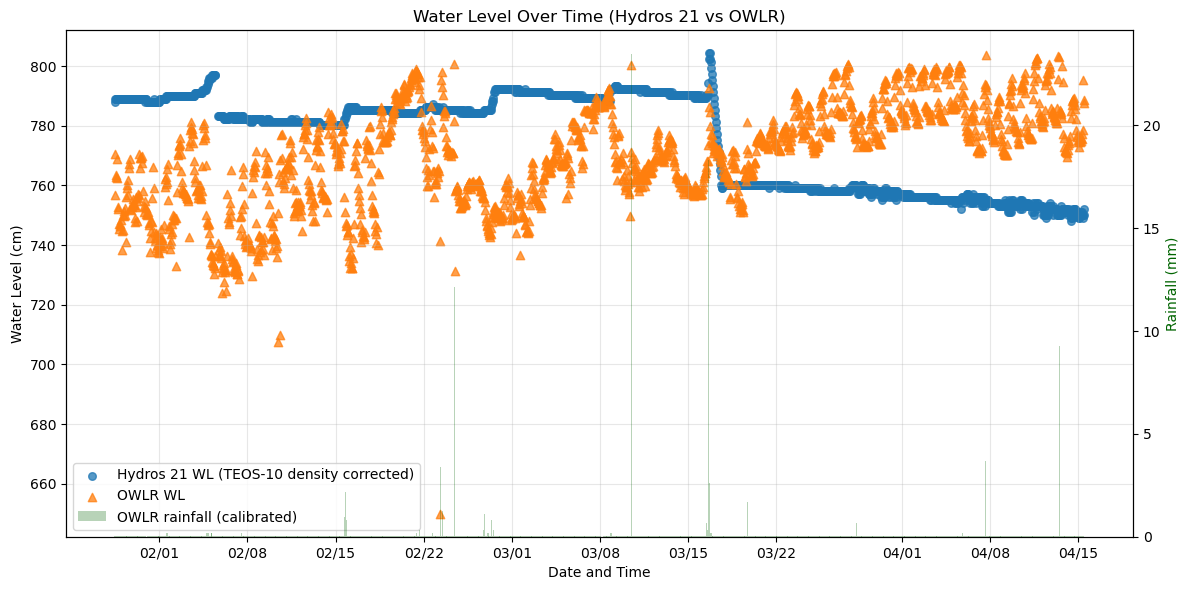

,timestamp_hour,WSE_CTD_cm,WSE_CTD_teos_cm,WSE_CTD_minus_TEOS_cm
0,2026-01-28 11:00:00,788.14,788.147294,-0.007294
1,2026-01-28 12:00:00,789.14,789.147379,-0.007379
2,2026-01-28 13:00:00,789.14,789.147379,-0.007379
3,2026-01-28 14:00:00,789.14,789.147379,-0.007379
4,2026-01-28 15:00:00,789.14,789.147379,-0.007379


In [19]:
import matplotlib.dates as mdates

# UNCW CMS Pond, Wilmington NC location for TEOS-10 SA calculation
SITE_LAT = 34.23
SITE_LON = -77.87

# Load full CTD data with temperature and conductivity columns
# Columns: Date & Time | Fluid Depth - cm | Temp - C | EC - dS/m
try:
    CTD_teos_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='utf-8')
except UnicodeDecodeError:
    try:
        CTD_teos_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='cp1252')
    except UnicodeDecodeError:
        CTD_teos_raw = pd.read_csv(wse_CTD_path, skiprows=5, encoding='latin1')
CTD_teos_raw.columns = [str(c).strip() for c in CTD_teos_raw.columns]

teos_time_col = CTD_teos_raw.columns[0]
teos_depth_col = CTD_teos_raw.columns[1]
teos_temp_col = CTD_teos_raw.columns[2]
teos_ec_col = CTD_teos_raw.columns[3]

CTD_teos_raw[teos_time_col] = pd.to_datetime(CTD_teos_raw[teos_time_col], errors='coerce')
CTD_teos_raw[teos_depth_col] = pd.to_numeric(CTD_teos_raw[teos_depth_col], errors='coerce')
CTD_teos_raw[teos_temp_col] = pd.to_numeric(CTD_teos_raw[teos_temp_col], errors='coerce')
CTD_teos_raw[teos_ec_col] = pd.to_numeric(CTD_teos_raw[teos_ec_col], errors='coerce')

# Keep only exact hourly marks within the comparison window
CTD_teos = CTD_teos_raw[
    CTD_teos_raw[teos_time_col].notna()
    & (CTD_teos_raw[teos_time_col].dt.minute == 0)
    & (CTD_teos_raw[teos_time_col].dt.second == 0)
    & (CTD_teos_raw[teos_time_col] >= start_time)
    & (CTD_teos_raw[teos_time_col] <= end_time)
].copy()  # Independent copy for safe downstream column edits

# Step 1: set units
CTD_teos['temp_C'] = CTD_teos[teos_temp_col]
CTD_teos['cond_mScm'] = CTD_teos[teos_ec_col]  # dS/m == mS/cm numerically

# Step 2: back-calculate pressure assuming rho = 1.000 g/cm^3
#  Calc I used is P (dbar) = rho * g * h / 10000  where rho=1000 kg/m^3, g=9.81 m/s^2, h in meters
CTD_teos['depth_m'] = CTD_teos[teos_depth_col] / 100.0
CTD_teos['P_dbar'] = 1000 * 9.81 * CTD_teos['depth_m'] / 10000

# Step 3: Practical Salinity from conductivity, temperature, pressure
CTD_teos['SP'] = gsw.SP_from_C(CTD_teos['cond_mScm'], CTD_teos['temp_C'], CTD_teos['P_dbar'])

# Step 4: Absolute Salinity
CTD_teos['SA'] = gsw.SA_from_SP(CTD_teos['SP'], CTD_teos['P_dbar'], SITE_LON, SITE_LAT)

# Step 5: Conservative Temperature
CTD_teos['CT'] = gsw.CT_from_t(CTD_teos['SA'], CTD_teos['temp_C'], CTD_teos['P_dbar'])

# Step 6: In-situ density (kg/m^3)
CTD_teos['rho'] = gsw.rho(CTD_teos['SA'], CTD_teos['CT'], CTD_teos['P_dbar'])

# Step 7: corrected depth using new time-varying density
CTD_teos['depth_corrected_cm'] = (CTD_teos['P_dbar'] * 10000) / (CTD_teos['rho'] * 9.81) * 100

# new CTD_teos wse within timeframe
CTD_teos['WSE_CTD_teos_cm'] = CTD_teos['depth_corrected_cm'] + 706.14
CTD_teos['timestamp_hour'] = CTD_teos[teos_time_col].dt.floor('h')
CTD_teos_hourly = CTD_teos[['timestamp_hour', 'WSE_CTD_teos_cm', 'rho', 'SP']]

# WSE_CTD - CTD_teos
ctd_delta = pd.merge(
    CTD_hourly[['timestamp_hour', 'WSE_CTD_cm']],
    CTD_teos_hourly[['timestamp_hour', 'WSE_CTD_teos_cm']],
    on='timestamp_hour',
    how='inner'
)
ctd_delta['WSE_CTD_minus_TEOS_cm'] = ctd_delta['WSE_CTD_cm'] - ctd_delta['WSE_CTD_teos_cm']

# Parse OWLR raw rain and calculate calibrated hourly rain using rainfallAnalysis coefficients
payload_parts = owlr_raw['data'].astype(str).str.split(',')
owlr_raw['rain_mm_raw'] = pd.to_numeric(payload_parts.str[2], errors='coerce')

owlr_rain_hourly = owlr_raw[
    owlr_raw['timestamp'].notna()
    & (owlr_raw['timestamp'] >= start_time)
    & (owlr_raw['timestamp'] <= end_time)
] .copy()
owlr_rain_hourly['timestamp_hour'] = owlr_rain_hourly['timestamp'].dt.floor('h')
owlr_rain_hourly = owlr_rain_hourly.groupby('timestamp_hour', as_index=False)['rain_mm_raw'].sum()

# From rainfallAnalysis.ipynb direct-comparison calibration: TR-525l = m * OWLR_raw + b
RAIN_CAL_M = 0.5404
RAIN_CAL_B = 0.0452
owlr_rain_hourly['rain_mm_owlr_cal'] = (RAIN_CAL_M * owlr_rain_hourly['rain_mm_raw'] + RAIN_CAL_B).clip(lower=0)

# Merge with OWLR
comparison_teos = pd.merge(CTD_teos_hourly, owlr, on='timestamp_hour', how='inner').dropna()
comparison_teos = comparison_teos.sort_values('timestamp_hour').reset_index(drop=True)

print(f'Matched TEOS-10 comparison points: {len(comparison_teos)}')
print(f'Mean density (kg/m^3):     {comparison_teos["rho"].mean():.4f}')
print(f'Mean Practical Salinity:  {comparison_teos["SP"].mean():.4f}')
print(f"Mean (WSE_CTD - CTD_teos) cm: {ctd_delta['WSE_CTD_minus_TEOS_cm'].mean():.4f}")

# Plot
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.scatter(
    comparison_teos['timestamp_hour'],
    comparison_teos['WSE_CTD_teos_cm'],
    s=30,
    marker='o',
    alpha=0.75,
    label='Hydros 21 WL (TEOS-10 density corrected)'
)
ax1.scatter(
    comparison_teos['timestamp_hour'],
    comparison_teos['WSE_OWLR_cm'],
    s=36,
    marker='^',
    alpha=0.75,
    label='OWLR WL'
)
ax2.bar(
    owlr_rain_hourly['timestamp_hour'],
    owlr_rain_hourly['rain_mm_owlr_cal'],
    width=0.045,
    color='darkgreen',
    alpha=0.28,
    label='OWLR rainfall (calibrated)'
)

ax1.set_title('Water Level Over Time (Hydros 21 vs OWLR)')
ax1.set_xlabel('Date and Time')
ax1.set_ylabel('Water Level (cm)')
ax2.set_ylabel('Rainfall (mm)', color='darkgreen')
ax1.grid(True, alpha=0.3)

# Force denser date ticks on the x-axis and format as MM/DD
date_locator = mdates.AutoDateLocator(minticks=12, maxticks=20)
date_formatter = mdates.DateFormatter('%m/%d')
ax1.xaxis.set_major_locator(date_locator)
ax1.xaxis.set_major_formatter(date_formatter)
plt.xticks(rotation=30)

handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(handles_1 + handles_2, labels_1 + labels_2, loc='lower left')

plt.tight_layout()
plt.show()

ctd_delta[['timestamp_hour', 'WSE_CTD_cm', 'WSE_CTD_teos_cm', 'WSE_CTD_minus_TEOS_cm']].head()

# OWLR wse and rainfall over time

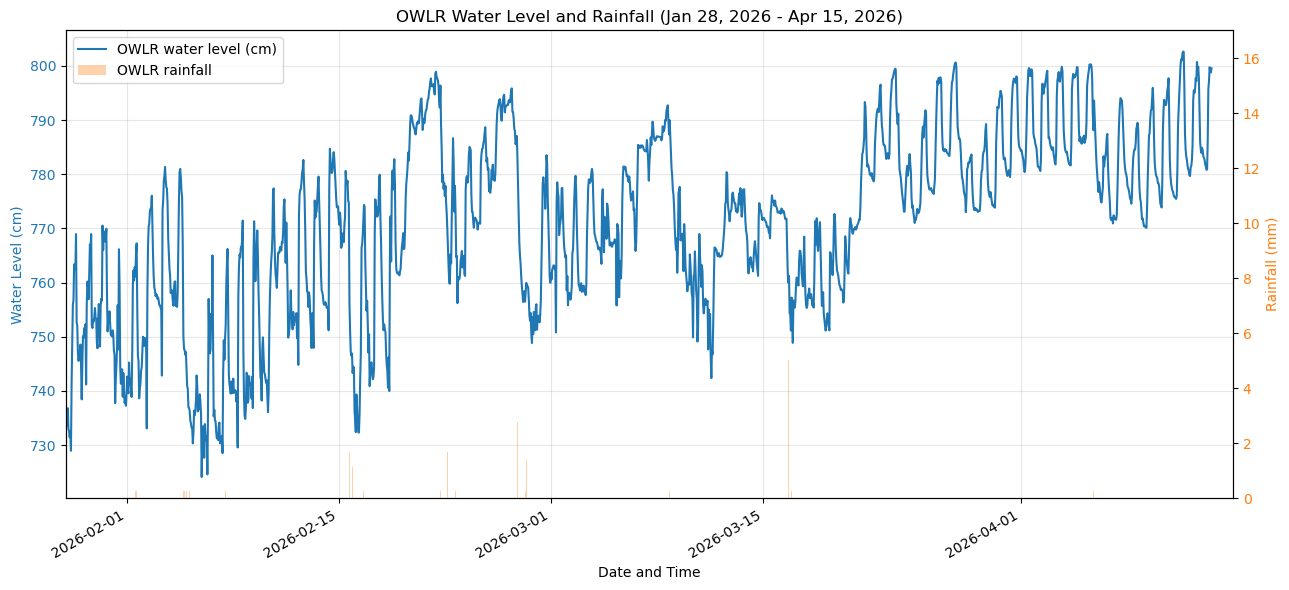

,timestamp,WSE_OWLR_cm,rain_mm
1009,2026-01-28 00:00:37,736.22500,0.0
1010,2026-01-28 01:00:38,733.81805,0.0
1011,2026-01-28 02:00:32,733.57777,0.0
1012,2026-01-28 03:00:39,736.80278,0.0
1013,2026-01-28 04:00:35,732.89722,0.0


In [13]:
owlr_plot_path = os.path.join('Data', 'OWLR_CMS_04132026.csv')
owlr_plot_start = pd.Timestamp('2026-01-28 00:00:00')
owlr_plot_end = pd.Timestamp('2026-04-14 23:59:59')

owlr_plot_raw = pd.read_csv(owlr_plot_path, header=None)
owlr_plot_raw = owlr_plot_raw.rename(columns={0: 'device_id', 1: 'timestamp', 2: 'unused_1', 3: 'unused_2', 4: 'data'})
owlr_plot_raw['timestamp'] = pd.to_datetime(owlr_plot_raw['timestamp'], errors='coerce')

plot_payload_parts = owlr_plot_raw['data'].astype(str).str.split(',')
owlr_plot_raw['OWLR_value_cm'] = pd.to_numeric(plot_payload_parts.str[1], errors='coerce')
owlr_plot_raw['rain_mm'] = pd.to_numeric(plot_payload_parts.str[2], errors='coerce')
owlr_plot_raw['WSE_OWLR_cm'] = 845 - owlr_plot_raw['OWLR_value_cm']

owlr_plot = owlr_plot_raw[
    owlr_plot_raw['timestamp'].notna()
    & (owlr_plot_raw['timestamp'] >= owlr_plot_start)
    & (owlr_plot_raw['timestamp'] <= owlr_plot_end)
].copy()

owlr_plot = owlr_plot[['timestamp', 'WSE_OWLR_cm', 'rain_mm']].dropna().sort_values('timestamp')

fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

ax1.plot(
    owlr_plot['timestamp'],
    owlr_plot['WSE_OWLR_cm'],
    color='tab:blue',
    linewidth=1.5,
    label='OWLR water level (cm)'
)
ax2.bar(
    owlr_plot['timestamp'],
    owlr_plot['rain_mm'],
    width=0.03,
    color='tab:orange',
    alpha=0.35,
    label='OWLR rainfall'
)

ax1.set_title('OWLR Water Level and Rainfall (Jan 28, 2026 - Apr 15, 2026)')
ax1.set_xlabel('Date and Time')
ax1.set_ylabel('Water Level (cm)', color='tab:blue')
ax2.set_ylabel('Rainfall (mm)', color='tab:orange')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax2.tick_params(axis='y', labelcolor='tab:orange')
ax1.set_xlim(owlr_plot_start, owlr_plot_end)
ax1.grid(True, alpha=0.3)

handles_1, labels_1 = ax1.get_legend_handles_labels()
handles_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(handles_1 + handles_2, labels_1 + labels_2, loc='upper left')

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

owlr_plot.head()

# CTD (noTEOS) vs OWLR scatter plot with best-fit line and R^2


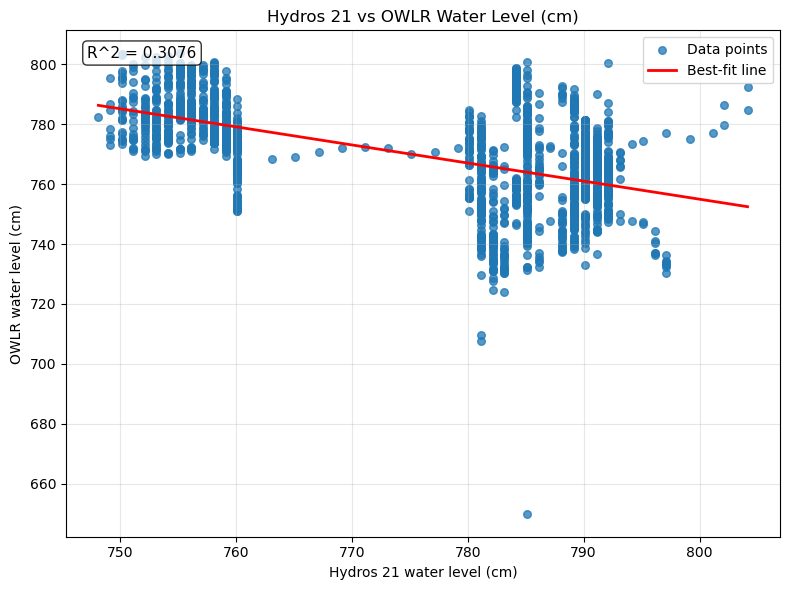

Best-fit line: y = -0.6043x + 1238.3870
R^2 = 0.3076


In [7]:
if 'comparison' not in globals() or comparison.empty:
    raise ValueError('Run Cell 3 first so comparison data is available.')

x = comparison['WSE_CTD_cm'].to_numpy()
y = comparison['WSE_OWLR_cm'].to_numpy()

# Linear best-fit line: y = m*x + b
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

# Coefficient of determination (R^2)
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=30, alpha=0.75, marker='o', label='Data points')

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red', linewidth=2, label='Best-fit line')

plt.title('Hydros 21 vs OWLR Water Level (cm)')
plt.xlabel('Hydros 21 water level (cm)')
plt.ylabel('OWLR water level (cm)')
plt.grid(True, alpha=0.3)
plt.legend()

# Add R^2 annotation on the graph
ax = plt.gca()
ax.text(
    0.03,
    0.97,
    f'R^2 = {r2:.4f}',
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print(f'Best-fit line: y = {m:.4f}x + {b:.4f}')
print(f'R^2 = {r2:.4f}')

# CTD TEOS-10 corrected vs OWLR scatter with best-fit line and R^2

Mean (WSE_CTD - CTD_teos) cm: -0.0672

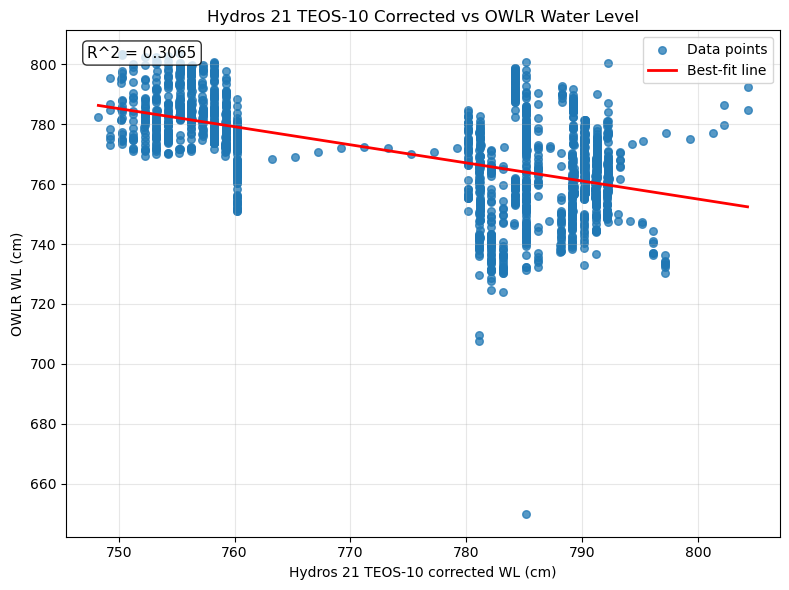

Best-fit line: y = -0.6040x + 1238.2012
R^2 = 0.3065


In [8]:
if 'comparison_teos' not in globals() or comparison_teos.empty:
    raise ValueError('Run Cell 4 first so TEOS comparison data is available.')

x = comparison_teos['WSE_CTD_teos_cm'].to_numpy()
y = comparison_teos['WSE_OWLR_cm'].to_numpy()

#best-fit line
m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

# R^2
ss_res = np.sum((y - y_fit) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (ss_res / ss_tot)

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=30, alpha=0.75, marker='o', label='Data points')

x_line = np.linspace(np.min(x), np.max(x), 200)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red', linewidth=2, label='Best-fit line')

plt.title('Hydros 21 TEOS-10 Corrected vs OWLR Water Level')
plt.xlabel('Hydros 21 TEOS-10 corrected WL (cm)')
plt.ylabel('OWLR WL (cm)')
plt.grid(True, alpha=0.3)
plt.legend()

ax = plt.gca()
ax.text(
    0.03,
    0.97,
    f'R^2 = {r2:.4f}',
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
)

plt.tight_layout()
plt.show()

print(f'Best-fit line: y = {m:.4f}x + {b:.4f}')
print(f'R^2 = {r2:.4f}')